/var/folders/yp/078pyxw11mq6g7sd_2ty18z80000gn/T/ipykernel_2426/1935777415.py:1: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import QuantumCircuit



GHZ STATE VS W STATE

GHZ STATE
--------------------------------------------------------------------------------

QUANTUM CIRCUIT
--------------------------------------------------------------------------------
     ┌───┐          
q_0: ┤ H ├──■────■──
     └───┘┌─┴─┐  │  
q_1: ─────┤ X ├──┼──
          └───┘┌─┴─┐
q_2: ──────────┤ X ├
               └───┘

MEASUREMENT RESULTS
--------------------------------------------------------------------------------
000 : 515
111 : 509

Expected GHZ outcomes:
000 and 111



W STATE
--------------------------------------------------------------------------------

QUANTUM CIRCUIT
--------------------------------------------------------------------------------
     ┌────────────────────────────────────────────────┐
q_0: ┤0                                               ├
     │                                                │
q_1: ┤1 Initialize(0,0.57735,0.57735,0,0.57735,0,0,0) ├
     │                                                │
q_2: ┤2      

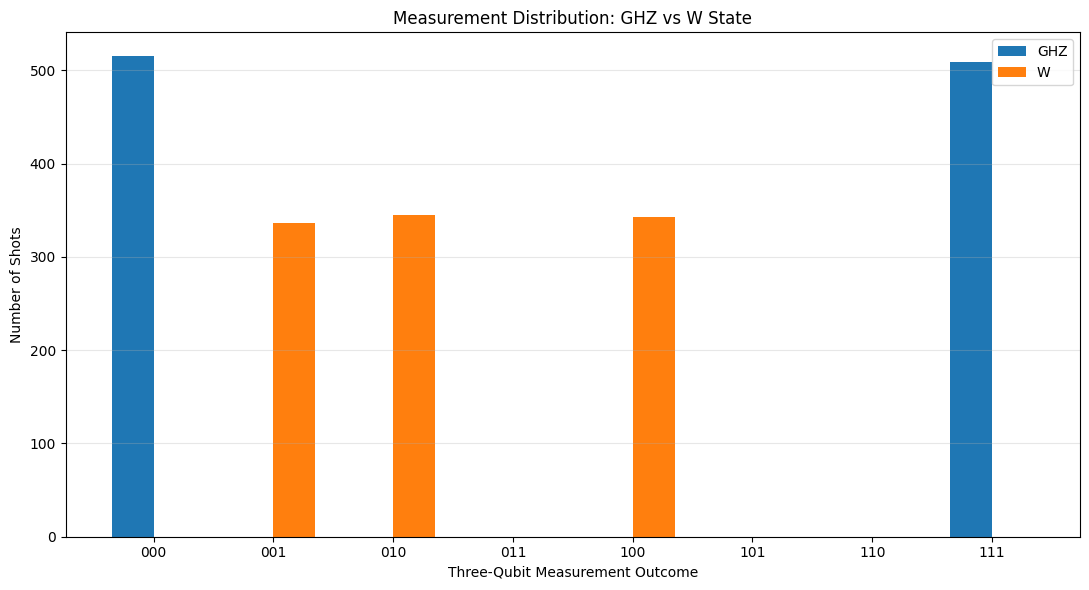

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np
import matplotlib.pyplot as plt

SHOTS = 1024
SEED = 42

rng = np.random.default_rng(SEED)

# --------------------------------------------------
# GHZ STATE
# --------------------------------------------------

ghz = QuantumCircuit(3)

ghz.h(0)
ghz.cx(0, 1)
ghz.cx(0, 2)

ghz_state = Statevector.from_instruction(
    ghz
)

ghz_probabilities = ghz_state.probabilities()

ghz_samples = rng.choice(
    np.arange(8),
    size=SHOTS,
    p=ghz_probabilities
)

ghz_counts = np.bincount(
    ghz_samples,
    minlength=8
)

# --------------------------------------------------
# W STATE
# --------------------------------------------------

w = QuantumCircuit(3)

w.initialize(
    [
        0,
        1 / np.sqrt(3),
        1 / np.sqrt(3),
        0,
        1 / np.sqrt(3),
        0,
        0,
        0
    ],
    [0, 1, 2]
)

w_state = Statevector.from_instruction(
    w
)

w_probabilities = w_state.probabilities()

w_samples = rng.choice(
    np.arange(8),
    size=SHOTS,
    p=w_probabilities
)

w_counts = np.bincount(
    w_samples,
    minlength=8
)

labels = [
    "000",
    "001",
    "010",
    "011",
    "100",
    "101",
    "110",
    "111"
]

print("\nGHZ STATE VS W STATE")
print("=" * 80)

# --------------------------------------------------
# GHZ OUTPUT
# --------------------------------------------------

print("\nGHZ STATE")
print("-" * 80)

print("\nQUANTUM CIRCUIT")
print("-" * 80)
print(ghz.draw())

print("\nMEASUREMENT RESULTS")
print("-" * 80)

for label, count in zip(
    labels,
    ghz_counts
):

    if count > 0:
        print(
            f"{label} : {count}"
        )

print("\nExpected GHZ outcomes:")
print("000 and 111")

# --------------------------------------------------
# W OUTPUT
# --------------------------------------------------

print("\n")
print("=" * 80)

print("\nW STATE")
print("-" * 80)

print("\nQUANTUM CIRCUIT")
print("-" * 80)
print(w.draw())

print("\nMEASUREMENT RESULTS")
print("-" * 80)

for label, count in zip(
    labels,
    w_counts
):

    if count > 0:
        print(
            f"{label} : {count}"
        )

print("\nExpected W outcomes:")
print("001, 010 and 100")

# --------------------------------------------------
# MEASURING FIRST QUBIT
# --------------------------------------------------

print("\n")
print("=" * 80)
print("BEHAVIOUR AFTER MEASURING QUBIT 0")
print("=" * 80)

print("\nGHZ STATE")
print("-" * 80)

ghz_q0_zero = (
    ghz_counts[0]
)

ghz_q0_one = (
    ghz_counts[4]
    + ghz_counts[5]
    + ghz_counts[6]
    + ghz_counts[7]
)

print(
    f"Qubit 0 = 0 : "
    f"{ghz_q0_zero}"
)

print(
    f"Qubit 0 = 1 : "
    f"{ghz_q0_one}"
)

print(
    "If qubit 0 = 0, remaining qubits "
    "collapse toward 00."
)

print(
    "If qubit 0 = 1, remaining qubits "
    "collapse toward 11."
)

print("\nW STATE")
print("-" * 80)

w_q0_zero = (
    w_counts[0]
    + w_counts[1]
    + w_counts[2]
    + w_counts[3]
)

w_q0_one = (
    w_counts[4]
    + w_counts[5]
    + w_counts[6]
    + w_counts[7]
)

print(
    f"Qubit 0 = 0 : "
    f"{w_q0_zero}"
)

print(
    f"Qubit 0 = 1 : "
    f"{w_q0_one}"
)

print(
    "If qubit 0 = 1, the remaining qubits "
    "collapse toward 00."
)

print(
    "If qubit 0 = 0, the remaining qubits "
    "retain a two-state superposition."
)

print("\nENTANGLEMENT COMPARISON")
print("-" * 80)

print(
    "GHZ : Strong global correlation. "
    "Measurement of one qubit determines "
    "the correlated value of the others."
)

print(
    "W   : Excitation is distributed among "
    "the three qubits. Measuring one qubit "
    "leaves a different entangled structure "
    "depending on the result."
)

# --------------------------------------------------
# VISUALIZATION
# --------------------------------------------------

x = np.arange(8)

fig, ax = plt.subplots(
    figsize=(11, 6)
)

width = 0.35

bars1 = ax.bar(
    x - width / 2,
    ghz_counts,
    width,
    label="GHZ"
)

bars2 = ax.bar(
    x + width / 2,
    w_counts,
    width,
    label="W"
)

ax.set_title(
    "Measurement Distribution: GHZ vs W State"
)

ax.set_xlabel(
    "Three-Qubit Measurement Outcome"
)

ax.set_ylabel(
    "Number of Shots"
)

ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()